In [1]:
# IMPORT NECESSARY LIBARIRES
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import recall_score, precision_score

print('Liberies well installed') 


Liberies well installed


In [2]:
df_data = pd.read_csv('data.csv')
df_data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
df_data.shape

(569, 32)

In [4]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df_data.head(20)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750


In [6]:
# Drop unneccessary Column
df_data = df_data.drop('id', axis=1)
df_data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
# Convert target to number
df_data['diagnosis'] = df_data['diagnosis'].str.strip()
df_data['diagnosis'] = df_data['diagnosis'].str.upper()
df_data['diagnosis'] = df_data['diagnosis'].map({'M': 1, 'B': 0})
df_data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
# Define Features and Target
X = df_data.drop("diagnosis", axis=1)
y = df_data ["diagnosis"]
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [9]:
y = df_data['diagnosis']
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [10]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


In [11]:
y_train

68     0
181    1
63     0
248    0
60     0
      ..
71     0
106    0
270    0
435    1
102    0
Name: diagnosis, Length: 455, dtype: int64

# LOGISTIC REGRESSION


In [12]:
#Define our Model(Logistic Regression)
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

logreg.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [13]:
logreg_pred = logreg.predict(X_test)
logreg_pred


array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1])

In [14]:
# Check for Accuracy
logreg_acc = accuracy_score(y_test, logreg_pred)

# Check for Classification Report
logreg_class = classification_report(y_test, logreg_pred)

# Check for Confusion Matrix
logreg_conf = confusion_matrix(y_test, logreg_pred)

# print out the Matrix
print('Accuracy score =\n', logreg_acc  * 100, '%')
print(' ')
print('::Classification Report::\n', logreg_class)
print(' ')
print('*******Confusion Matrix*******\n', logreg_conf)


Accuracy score =
 97.36842105263158 %
 
::Classification Report::
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

 
*******Confusion Matrix*******
 [[70  1]
 [ 2 41]]


In [15]:
# Cross Vaildation(Logistic Regression)
cv_scores = cross_val_score(logreg, X, y, cv=5)
print("Logistic Regression CV Scores:", cv_scores*100)
print("Logistic Regression Mean CV Score:", cv_scores.mean()*100)


Logistic Regression CV Scores: [98.24561404 98.24561404 97.36842105 97.36842105 99.11504425]
Logistic Regression Mean CV Score: 98.06862288464524


In [16]:
# Hyperparameter Tuning(Logistic Regression)
param_grid = {
    "logisticregression__C": [0.1, 1, 10]
}

# GridSearch
grid_logreg = GridSearchCV(logreg, param_grid, cv=5)

# Fit
grid_logreg.fit(X_train, y_train)
    

,estimator,Pipeline(step..._iter=2000))])
,param_grid,"{'logisticregression__C': [0.1, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [17]:
# Best Model(Logistics Regression)
best_params = grid_logreg.best_params_
print(best_params)

{'logisticregression__C': 1}


In [18]:
best_log = grid_logreg.best_estimator_
log_opt_pred = best_log.predict(X_test)
log_opt_acc = accuracy_score(y_test, log_opt_pred)
print("Optimized Logistic Accuracy:", log_opt_acc)

Optimized Logistic Accuracy: 0.9736842105263158


# DECISION TREE

In [19]:
# DEFINE MODEL (Decision Tree)
dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
dec_tree_pred = dec_tree.predict(X_test)
dec_tree_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1])

In [21]:
# Check for Accuracy
dec_tree_acc = accuracy_score(y_test, dec_tree_pred)

# Check for Classification Report
dec_tree_class = classification_report(y_test, dec_tree_pred)

# Check for Confusion Matrix
dec_tree_conf = confusion_matrix(y_test, dec_tree_pred)

# print out the Matrix
print('Accuracy score =\n', dec_tree_acc  * 100, '%')
print(' ')
print('::Classification Report::\n', dec_tree_class)
print(' ')
print('*******Confusion Matrix*******\n', dec_tree_conf)


Accuracy score =
 92.98245614035088 %
 
::Classification Report::
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114

 
*******Confusion Matrix*******
 [[67  4]
 [ 4 39]]


In [22]:
# Cross Vaildation
cv_scores = cross_val_score(dec_tree, X, y, cv=5)
print("Decision Tree CV Scores:", cv_scores*100)
print("Decision Tree Mean CV Score:", cv_scores.mean()*100)


Decision Tree CV Scores: [90.35087719 90.35087719 92.10526316 93.85964912 90.26548673]
Decision Tree Mean CV Score: 91.38643067846608


In [23]:
# TUNING
param_grid_dec_tree = {
    "max_depth": [2, 6, 12],
    "min_samples_split": [12, 40, 48]
    }
grid_dec_tree = GridSearchCV(dec_tree, param_grid_dec_tree, cv=5)
grid_dec_tree.fit(X_train, y_train)


,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [2, 6, ...], 'min_samples_split': [12, 40, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [24]:
# BEST MODEL(DECISION TREE)
best_params = grid_dec_tree.best_params_
print(best_params)

{'max_depth': 12, 'min_samples_split': 12}


In [25]:
best_dec = grid_dec_tree.best_estimator_
dec_opt_pred = best_dec.predict(X_test)
dec_opt_accuracy = accuracy_score(y_test, dec_opt_pred)
print("Optimized Decision Tree Accuracy:", dec_opt_accuracy)


Optimized Decision Tree Accuracy: 0.9473684210526315


# RANDOM FOREST

In [26]:
# Define Model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
rf_pred = rf.predict(X_test)
rf_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [28]:
# Check for Accuracy
rf_acc = accuracy_score(y_test, rf_pred)

# Check for Classification Report
rf_class = classification_report(y_test, rf_pred)

# Check for Confusion Matrix
rf_conf = confusion_matrix(y_test, rf_pred)

# print out the Matrix
print('Accuracy score =\n', rf_acc  * 100, '%')
print(' ')
print('::Classification Report::\n', rf_class)
print(' ')
print('*******Confusion Matrix*******\n', rf_conf)


Accuracy score =
 96.49122807017544 %
 
::Classification Report::
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

 
*******Confusion Matrix*******
 [[70  1]
 [ 3 40]]


In [29]:
# Cross Vaildation
cv_scores = cross_val_score(rf, X, y, cv=5)
print("Random Forest CV Scores:", cv_scores*100)
print("Random Forest Mean CV Score:", cv_scores.mean()*100)


Random Forest CV Scores: [92.98245614 94.73684211 98.24561404 97.36842105 96.46017699]
Random Forest Mean CV Score: 95.95870206489676


In [30]:
# TUNING
param_grid_rf = {
    "n_estimators": [10, 20, 50],
    "max_depth": [3, 10, 15]
    }
grid_rf = GridSearchCV(rf, param_grid_rf, cv=8)
grid_rf.fit(X_train, y_train)


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [3, 10, ...], 'n_estimators': [10, 20, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,8
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [31]:
# BEST MODEL(Random Forest )
best_params = grid_rf.best_params_
print(best_params)

{'max_depth': 15, 'n_estimators': 50}


In [32]:
best_rf = grid_rf.best_estimator_
rf_opt_pred = best_rf.predict(X_test)
rf_opt_accuracy = accuracy_score(y_test, rf_opt_pred)
print("Optimized Random Forest Accuracy:", rf_opt_accuracy)


Optimized Random Forest Accuracy: 0.9649122807017544


# Gaussian Naive Bayes

In [33]:
# Define Model
nb = GaussianNB()
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [34]:
nb_pred = nb.predict(X_test)
nb_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [35]:
# Check for Accuracy
nb_acc = accuracy_score(y_test, nb_pred)

# Check for Classification Report
nb_class = classification_report(y_test, nb_pred)

# Check for Confusion Matrix
nb_conf = confusion_matrix(y_test, nb_pred)

# print out the Matrix
print('Accuracy score =\n', nb_acc  * 100, '%')
print(' ')
print('::Classification Report::\n', nb_class)
print(' ')
print('*******Confusion Matrix*******\n', nb_conf)


Accuracy score =
 97.36842105263158 %
 
::Classification Report::
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

 
*******Confusion Matrix*******
 [[71  0]
 [ 3 40]]


In [36]:
# Cross Vaildation
cv_scores = cross_val_score(nb, X, y, cv=5)
print("Gaussian naive Bayes CV Scores:", cv_scores*100)
print("Gaussian naive Bayes Mean CV Score:", cv_scores.mean()*100)


Gaussian naive Bayes CV Scores: [92.10526316 92.10526316 94.73684211 94.73684211 95.57522124]
Gaussian naive Bayes Mean CV Score: 93.85188635305074


In [37]:
# Hyperparameter Tuning
param_grid = {
    "var_smoothing": [0.1, 1, 10]
}

# GridSearch
grid_nb = GridSearchCV(nb, param_grid, cv=5)

# Fit
grid_nb.fit(X_train, y_train)

,estimator,GaussianNB()
,param_grid,"{'var_smoothing': [0.1, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [38]:
# Best Model
best_params = grid_nb.best_params_
print(best_params)

{'var_smoothing': 0.1}


In [39]:
best_nb = grid_nb.best_estimator_
nb_opt_pred = best_nb.predict(X_test)
nb_opt_accuracy = accuracy_score(y_test, nb_opt_pred)
print("Optimized Gaussian Naive Bayes Accuracy:", nb_opt_accuracy)


Optimized Gaussian Naive Bayes Accuracy: 0.9385964912280702


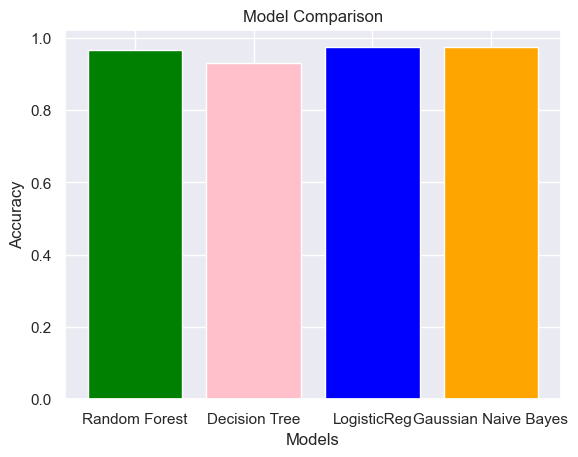

In [40]:
# Visualiation 
model_names = ('Random Forest', 'Decision Tree', 'LogisticReg', 'Gaussian Naive Bayes')
scores = (rf_acc, dec_tree_acc, logreg_acc, nb_acc)

plt.bar(model_names, scores, color =['Green', 'Pink', 'Blue', 'Orange'])
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

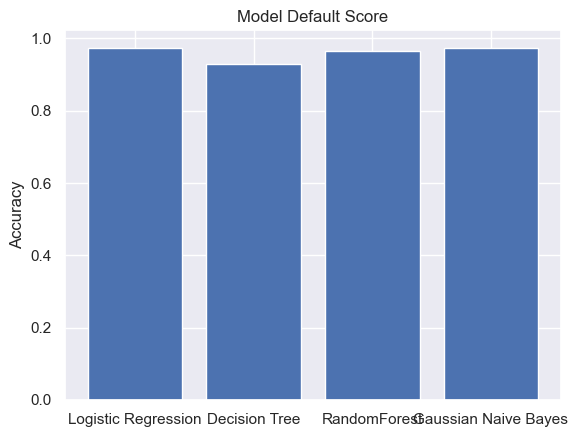

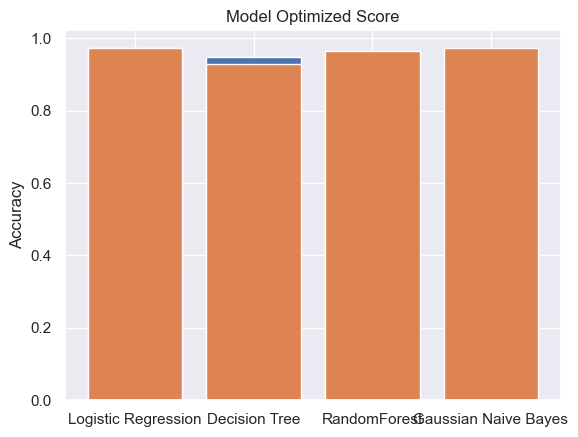

In [41]:
# Comparing Models 
models = ["Logistic Regression", "Decision Tree", "RandomForest",  "Gaussian Naive Bayes"]
default_scores = [logreg_acc, dec_tree_acc, rf_acc, nb_acc]
optimized_scores = [log_opt_acc, dec_opt_accuracy, rf_opt_accuracy, nb_opt_accuracy]
x = range(len(models))
plt.bar(x, default_scores)
plt.xticks(x, models)
plt.title("Model Default Score")
plt.ylabel("Accuracy")
plt.show()

plt.bar(x, optimized_scores)
x = range(len(models))
plt.bar(x, default_scores)
plt.xticks(x, models)
plt.title("Model Optimized Score")
plt.ylabel("Accuracy")
plt.show()


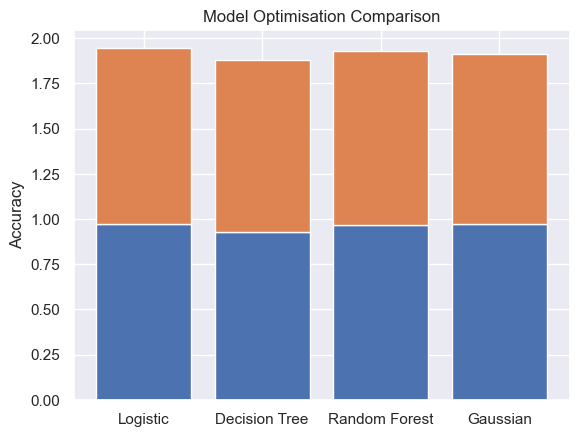

In [42]:
models = ["Logistic", "Decision Tree", "Random Forest", "Gaussian"]
default_scores = [logreg_acc, dec_tree_acc, rf_acc, nb_acc]
optimized_scores = [log_opt_acc, dec_opt_accuracy, rf_opt_accuracy, nb_opt_accuracy]
x = range(len(models))
plt.bar(x, default_scores)
plt.bar(x, optimized_scores, bottom = default_scores)
plt.xticks(x, models)
plt.title("Model Optimisation Comparison")
plt.ylabel("Accuracy")
plt.show()

In [43]:
# Get feature importance (Logistic Regression)
logreg_model = logreg.named_steps['logisticregression']

logreg_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': logreg_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

print(logreg_importance.head(10))

                 Feature  Importance
21         texture_worst    1.350606
10             radius_se    1.268178
28        symmetry_worst    1.208200
7    concave_points_mean    1.119804
26       concavity_worst    0.943053
13               area_se    0.907186
20          radius_worst    0.879840
23            area_worst    0.841846
6         concavity_mean    0.801458
27  concave_points_worst    0.778217


In [44]:
# Get feature importance(Decision Tree)
dec_tree_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dec_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(dec_tree_importance.head(10))

                 Feature  Importance
7    concave_points_mean    0.691420
27  concave_points_worst    0.065651
20          radius_worst    0.052299
22       perimeter_worst    0.051494
21         texture_worst    0.040185
1           texture_mean    0.027669
16          concavity_se    0.018554
17     concave_points_se    0.015931
10             radius_se    0.011983
14         smoothness_se    0.009306


In [45]:
# Get feature importance (Random Forest)
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance.head(10))

                 Feature  Importance
22       perimeter_worst    0.153506
7    concave_points_mean    0.137541
20          radius_worst    0.130418
27  concave_points_worst    0.120072
23            area_worst    0.091264
3              area_mean    0.067680
2         perimeter_mean    0.034019
0            radius_mean    0.031930
26       concavity_worst    0.030038
6         concavity_mean    0.029381


In [46]:
# Get features importance (Gaussian naive bayes)
nb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(nb.theta_[0] - nb.theta_[1])
}).sort_values(by='Importance', ascending=False)

print(nb_importance.head(10))

            Feature  Importance
23       area_worst  848.337601
3         area_mean  510.102770
22  perimeter_worst   53.471797
13          area_se   50.492541
2    perimeter_mean   36.798868
20     radius_worst    7.624197
21    texture_worst    5.861493
0       radius_mean    5.248867
1      texture_mean    3.670664
12     perimeter_se    2.266002
